<a href="https://colab.research.google.com/github/RiyaBisht716/Loan-Prediction/blob/main/Loan_PredictionUsing_Ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [3]:
# loan_approval_ann.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


Load and Explore Data

In [4]:
# Load dataset
df = pd.read_csv("/content/loanPrediction.csv")
print("Dataset shape:", df.shape)
print(df.head())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Fill or drop missing data
df.fillna(df.median(numeric_only=True), inplace=True)


Dataset shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural          

data preprocessing


In [5]:
# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Separate features and target
X = df.drop("Loan_Status", axis=1)  # target column should be named 'Loan_Status'
y = df["Loan_Status"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Build an ann


In [6]:
# Build ANN model
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # binary output
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6549 - loss: 0.6587 - val_accuracy: 0.7826 - val_loss: 0.6224
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6929 - loss: 0.6276 - val_accuracy: 0.8043 - val_loss: 0.5863
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7255 - loss: 0.6037 - val_accuracy: 0.8152 - val_loss: 0.5571
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7174 - loss: 0.5950 - val_accuracy: 0.8043 - val_loss: 0.5370
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7772 - loss: 0.5519 - val_accuracy: 0.8043 - val_loss: 0.5206
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7663 - loss: 0.5563 - val_accuracy: 0.7935 - val_loss: 0.5149
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7826 - loss: 0.5307 - val_accuracy: 0.7935 - val_loss: 0.5101
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7799 - loss: 0.5388 - val_accuracy: 0.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8571 - loss: 0.4026 

Test Accuracy: 85.71%
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


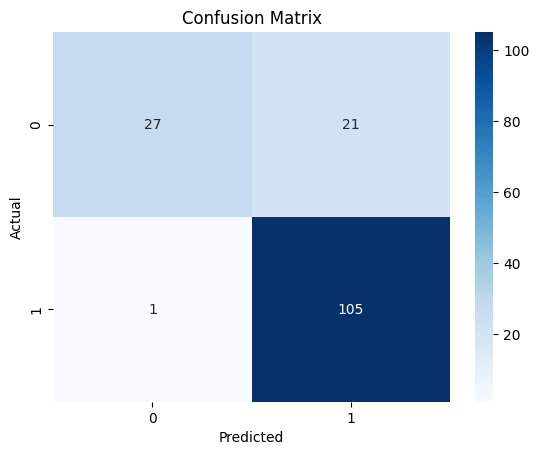


Classification Report:

              precision    recall  f1-score   support

           0     0.9643    0.5625    0.7105        48
           1     0.8333    0.9906    0.9052       106

    accuracy                         0.8571       154
   macro avg     0.8988    0.7765    0.8078       154
weighted avg     0.8741    0.8571    0.8445       154



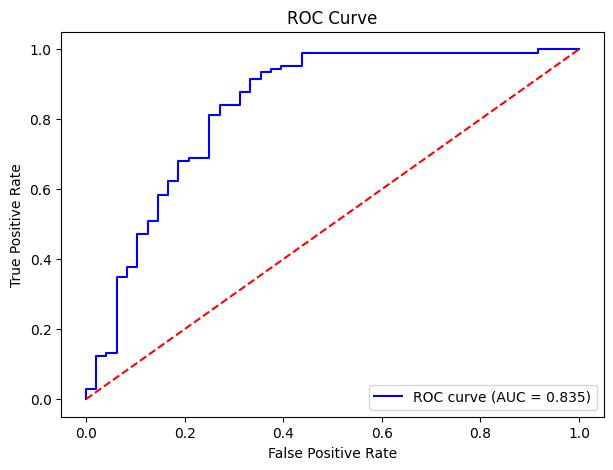

In [7]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# Predictions
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


training visualization

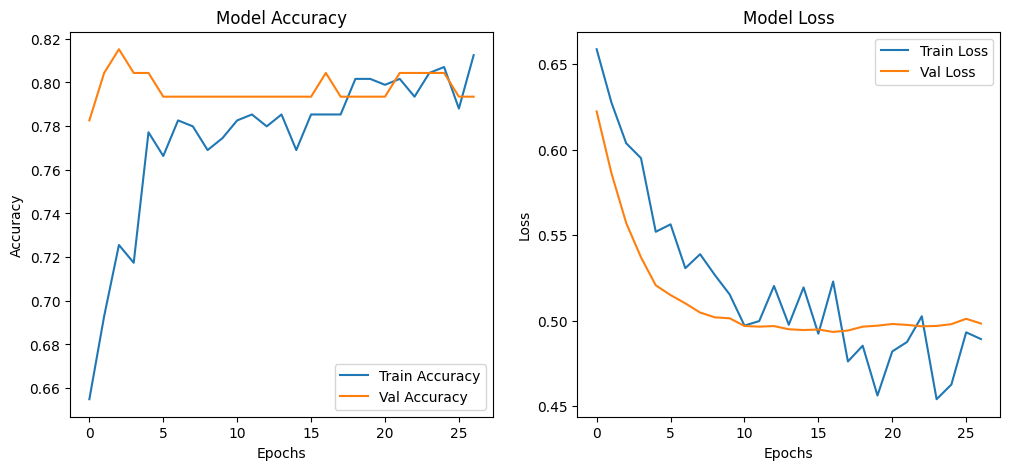

In [8]:
# Plot training history
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


saving model

In [9]:
# Model summary
model.summary()

# Save the model
model.save("loan_approval_ann_model.h5")
print("Model saved successfully!")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,373 (40.52 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,916 (27.02 KB)

Model saved successfully!


Example


In [10]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ----------------------------
# 1. Load trained model
# ----------------------------
model = load_model("/content/loan_approval_ann_model.h5")

# ----------------------------
# 2. Load dataset (same as training)
# ----------------------------
df = pd.read_csv("/content/loanPrediction.csv")

# Numeric missing ko median se fill kiya tha training mein
df.fillna(df.median(numeric_only=True), inplace=True)

# Loan_Status ko 0/1 bana lo agar Y/N hai
if df["Loan_Status"].dtype == "object":
    df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

# Features
X = df.drop("Loan_Status", axis=1)

# ----------------------------
# 3. Encode categorical columns (SAME as training)
# ----------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # training time bhi yahi kiya tha: poori column ko encode
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Ab saare columns numeric hain
numeric_cols = X.columns  # model isi pe train hua

print("Number of features used by model:", X.shape[1])

# ----------------------------
# 4. Fit scaler on X
# ----------------------------
scaler = StandardScaler()
scaler.fit(X)

# ----------------------------
# 5. User input (YOU CAN CHANGE THIS)
# ----------------------------
input_data = {
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "1",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 7500,
    "CoapplicantIncome": 2000,
    "LoanAmount": 250,
    "Loan_Amount_Term": 360,
    "Credit_History": 1,
    "Property_Area": "Urban",
}

# Loan_ID bhi feature mein tha training ke time,
# isliye yahan koi valid ID daalna zaroori hai:
input_row = input_data.copy()
input_row["Loan_ID"] = df["Loan_ID"].iloc[0]  # ya df["Loan_ID"].mode()[0]

input_df = pd.DataFrame([input_row])

# ----------------------------
# 6. Same preprocessing on input
# ----------------------------

# 6.1. Fill numeric missing (if any) — ab X numeric hai,
# isliye median X se lo, df se nahi
X_medians = X.median()

for col in X_medians.index:
    if col in input_df.columns:
        input_df[col] = input_df[col].fillna(X_medians[col])

# 6.2. Encode categoricals with SAME label_encoders
for col in categorical_cols:
    if col in input_df.columns:
        # Agar user ne koi unseen category de di to error aayega,
        # isliye safe side par: agar value unknown ho to mode use karo
        for i, val in input_df[col].items():
            if val not in label_encoders[col].classes_:
                # replace with training mode
                input_df.at[i, col] = df[col].mode()[0]

        input_df[col] = label_encoders[col].transform(input_df[col])
    else:
        # Agar column hi missing ho to training ka mode lo
        most_common = df[col].mode()[0]
        temp_series = pd.Series([most_common])
        temp_encoded = label_encoders[col].transform(temp_series)
        input_df[col] = temp_encoded[0]

# 6.3. Make sure columns order EXACTLY same as X
# Agar koi column missing ho to 0 de do
for col in X.columns:
    if col not in input_df.columns:
        input_df[col] = 0

input_df = input_df[X.columns]

# ----------------------------
# 7. Scale & predict
# ----------------------------
input_scaled = scaler.transform(input_df)

pred = model.predict(input_scaled)
prob = float(pred[0][0])
predicted_class = int(prob > 0.5)

print(f"\nPredicted Probability: {prob:.4f}")
print("✅ Loan Approved" if predicted_class == 1 else "❌ Loan Rejected")



Number of features used by model: 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

Predicted Probability: 0.6973
✅ Loan Approved
